# Step 7 — Walk-Forward Validation

A single train/test split is sensitive to where the cutoff year falls. Walk-forward validation uses an **expanding window**: the model is retrained at each step with all data available up to that point, then tested on the next unseen period.

This gives 6 evaluation folds across 1999–2018, producing more robust and publishable performance estimates.

| Fold | Train years | Test years |
|------|-------------|------------|
| 1    | 1999–2005   | 2006–2007  |
| 2    | 1999–2007   | 2008–2009  |
| 3    | 1999–2009   | 2010–2011  |
| 4    | 1999–2011   | 2012–2013  |
| 5    | 1999–2013   | 2014–2015  |
| 6    | 1999–2015   | 2016–2017  |

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score, brier_score_loss
)

print('All imports successful!')

All imports successful!


In [2]:
df = pd.read_csv('../data/american_bankruptcy_dataset.csv')
df['target'] = (df['status_label'] == 'failed').astype(int)

FEATURES = ['X1','X2','X3','X4','X5','X6','X7','X8',
            'X9','X10','X11','X12','X13','X14','X15',
            'X16','X17','X18','Division']
cat_idx = [FEATURES.index('Division')]

# Load best params from tuning
meta = joblib.load('../model/app_metadata.joblib')
tuned = meta.get('tuned_params', {'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 3})
print(f'Using tuned params: {tuned}')

# Walk-forward folds: (train_end, test_start, test_end)
folds = [
    (2005, 2006, 2007),
    (2007, 2008, 2009),
    (2009, 2010, 2011),
    (2011, 2012, 2013),
    (2013, 2014, 2015),
    (2015, 2016, 2017),
]
print(f'Number of folds: {len(folds)}')

Using tuned params: {'depth': 6, 'learning_rate': np.float64(0.05), 'l2_leaf_reg': np.float64(5.0)}
Number of folds: 6


## Run Walk-Forward Validation

In [3]:
THRESHOLD = 0.4
fold_results = []

for fold_num, (train_end, test_start, test_end) in enumerate(folds, 1):
    train_df = df[df['fyear'] <= train_end]
    test_df  = df[(df['fyear'] >= test_start) & (df['fyear'] <= test_end)]

    X_train, y_train = train_df[FEATURES], train_df['target']
    X_test,  y_test  = test_df[FEATURES],  test_df['target']

    # Use 20% of training tail as internal val for early stopping
    val_cutoff = int(len(train_df) * 0.8)
    X_val_fold = X_train.iloc[val_cutoff:]
    y_val_fold = y_train.iloc[val_cutoff:]
    X_tr_fold  = X_train.iloc[:val_cutoff]
    y_tr_fold  = y_train.iloc[:val_cutoff]

    tr_pool  = Pool(X_tr_fold,  y_tr_fold,  cat_features=cat_idx)
    val_pool = Pool(X_val_fold, y_val_fold, cat_features=cat_idx)
    te_pool  = Pool(X_test,     y_test,     cat_features=cat_idx)

    m = CatBoostClassifier(
        iterations=500,
        learning_rate=tuned['learning_rate'],
        depth=int(tuned['depth']),
        l2_leaf_reg=tuned['l2_leaf_reg'],
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=42,
        early_stopping_rounds=50,
        scale_pos_weight=6,
        verbose=False
    )
    m.fit(tr_pool, eval_set=val_pool)

    proba = m.predict_proba(te_pool)[:, 1]
    preds = (proba >= THRESHOLD).astype(int)

    auc       = roc_auc_score(y_test, proba)
    brier     = brier_score_loss(y_test, proba)
    f1_failed = f1_score(y_test, preds, pos_label=1, zero_division=0)
    rec       = recall_score(y_test, preds, pos_label=1)
    prec      = precision_score(y_test, preds, pos_label=1, zero_division=0)
    n_failed  = int(y_test.sum())

    fold_results.append({
        'Fold': fold_num,
        'Train years': f'1999–{train_end}',
        'Test years':  f'{test_start}–{test_end}',
        'Test failed': n_failed,
        'AUC':         round(auc, 4),
        'Brier':       round(brier, 5),
        'Failed Recall':    round(rec,  3),
        'Failed Precision': round(prec, 3),
        'Failed F1':        round(f1_failed, 3),
    })
    print(f'Fold {fold_num} (test {test_start}–{test_end}): '
          f'AUC={auc:.4f}  F1={f1_failed:.3f}  Recall={rec:.3f}  n_failed={n_failed}')

results_df = pd.DataFrame(fold_results).set_index('Fold')
print('\nDone.')

Fold 1 (test 2006–2007): AUC=0.7104  F1=0.278  Recall=0.534  n_failed=702
Fold 2 (test 2008–2009): AUC=0.7134  F1=0.223  Recall=0.585  n_failed=518
Fold 3 (test 2010–2011): AUC=0.7629  F1=0.223  Recall=0.570  n_failed=412
Fold 4 (test 2012–2013): AUC=0.8088  F1=0.229  Recall=0.653  n_failed=349
Fold 5 (test 2014–2015): AUC=0.8128  F1=0.189  Recall=0.648  n_failed=253
Fold 6 (test 2016–2017): AUC=0.8310  F1=0.138  Recall=0.636  n_failed=140

Done.


## Results Table

In [4]:
print(results_df.to_string())
print()
numeric_cols = ['AUC', 'Brier', 'Failed Recall', 'Failed Precision', 'Failed F1']
means = results_df[numeric_cols].mean().round(4)
stds  = results_df[numeric_cols].std().round(4)
print('Mean across folds:')
print(means.to_string())
print('\nStd across folds:')
print(stds.to_string())

     Train years Test years  Test failed     AUC    Brier  Failed Recall  Failed Precision  Failed F1
Fold                                                                                                 
1      1999–2005  2006–2007          702  0.7104  0.12686          0.534             0.188      0.278
2      1999–2007  2008–2009          518  0.7134  0.13137          0.585             0.138      0.223
3      1999–2009  2010–2011          412  0.7629  0.11706          0.570             0.138      0.223
4      1999–2011  2012–2013          349  0.8088  0.11477          0.653             0.139      0.229
5      1999–2013  2014–2015          253  0.8128  0.10492          0.648             0.110      0.189
6      1999–2015  2016–2017          140  0.8310  0.09748          0.636             0.078      0.138

Mean across folds:
AUC                 0.7732
Brier               0.1154
Failed Recall       0.6043
Failed Precision    0.1318
Failed F1           0.2133

Std across folds:
AUC       

## AUC Over Time

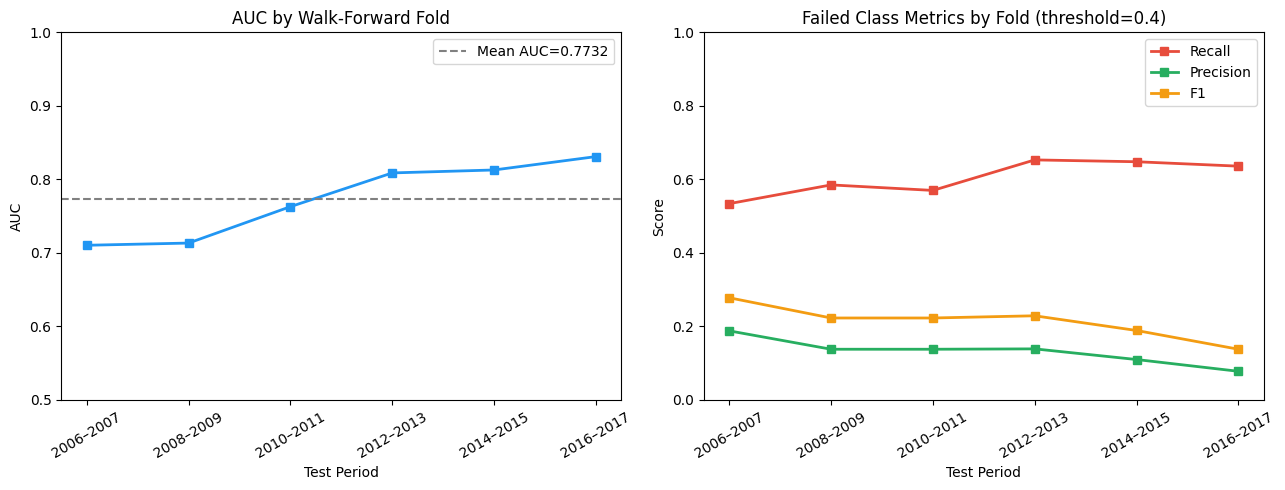

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

test_labels = [f'{ts}–{te}' for _, ts, te in folds]

ax = axes[0]
ax.plot(test_labels, results_df['AUC'], 's-', color='#2196F3', lw=2)
ax.axhline(results_df['AUC'].mean(), color='grey', linestyle='--', label=f'Mean AUC={results_df["AUC"].mean():.4f}')
ax.set_xlabel('Test Period')
ax.set_ylabel('AUC')
ax.set_title('AUC by Walk-Forward Fold')
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.tick_params(axis='x', rotation=30)

ax2 = axes[1]
ax2.plot(test_labels, results_df['Failed Recall'],    's-', color='#E74C3C', lw=2, label='Recall')
ax2.plot(test_labels, results_df['Failed Precision'], 's-', color='#27AE60', lw=2, label='Precision')
ax2.plot(test_labels, results_df['Failed F1'],        's-', color='#F39C12', lw=2, label='F1')
ax2.set_xlabel('Test Period')
ax2.set_ylabel('Score')
ax2.set_title('Failed Class Metrics by Fold (threshold=0.4)')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()